# Analysis of Example 1: waiting time, fluorescence window and selection rule

This notebook starts from the results of `examples/example1_two_level_open.ipynb` and tests the open two-level system against analytical formulas. In this notebook you will:

- load the calculation saved by the example and check the linewidth of its peak;
- follow the two pathways as a function of the waiting time $t_2$;
- compare the integrated fluorescence with $1-e^{-\gamma_1T}$ as a function of the window $T$;
- show which fourth interaction closes the response onto a population (selection rule);
- compare the exact and the trapezoidal evaluation of the jump integral.

Every study needs only the peak point $(\omega_{1Q},\omega_{\rm emit})=(-\omega_{eg},+\omega_{eg})$, so the calculations are fast.

Natural units: $\hbar=1$, energies and rates in eV, times in eV$^{-1}$.

## 0. Imports

`models.py` (in the parent folder) holds the model of the example, so that the analysis uses the same one. Figures are saved in `results/figure_analysis/`.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from qudpy_fdgf import ObservableSpec, SpectroscopySolver
from models import EX1, EX1_PATHWAYS, EX1_PROTOCOL, ANALYSIS_FIGURES, DATA, example1_model, results_dirs

results_dirs()
omega_eg, gamma_1, gamma_phi, eta = EX1["omega_eg"], EX1["gamma_1"], EX1["gamma_phi"], EX1["eta"]

## 1. Results of the example

The example saved its parameters, the $101\times101$ rephasing map and the three observables. We load them; nothing is recomputed here.

In [2]:
saved = np.load(DATA / "example1.npz")
omega_1q, omega_emit = saved["omega_1q_fine"], saved["omega_emit_fine"]
rephasing = saved["rephasing_fine"]

assert saved["gamma_1"] == gamma_1 and saved["gamma_phi"] == gamma_phi
print(f"saved map: {rephasing.shape}, t2 = {saved['t2']}, peak |S| = {np.abs(rephasing).max():.4f}")

saved map: (101, 101), t2 = 10.0, peak |S| = 38.6076


### Linewidth of the peak

Along the emission axis, a pole of the resolvent at $\omega_{eg}-i(\gamma_2+\eta)$ gives a Lorentzian whose *modulus* has half maximum at $\pm\sqrt3\,\Gamma$ from the centre, with $\Gamma=\gamma_2+\eta$ and $\gamma_2=\gamma_1/2+\gamma_\phi$. The full width at half maximum of $|S|$ is therefore $2\sqrt3\,\Gamma$.

In [3]:
i = np.argmin(np.abs(omega_1q + omega_eg))
cut = np.abs(rephasing[i])
half = cut.max() / 2
above = np.flatnonzero(cut >= half)
# linear interpolation of the two half-maximum crossings
left = np.interp(half, [cut[above[0] - 1], cut[above[0]]], [omega_emit[above[0] - 1], omega_emit[above[0]]])
right = np.interp(half, [cut[above[-1] + 1], cut[above[-1]]], [omega_emit[above[-1] + 1], omega_emit[above[-1]]])

gamma_2 = gamma_1 / 2 + gamma_phi
fwhm, expected = right - left, 2 * np.sqrt(3) * (gamma_2 + eta)
print(f"FWHM of |S| along omega_emit: {fwhm:.4f} eV; expected 2*sqrt(3)*(gamma_2 + eta) = {expected:.4f} eV")
assert abs(fwhm - expected) < 0.01

FWHM of |S| along omega_emit: 0.1801 eV; expected 2*sqrt(3)*(gamma_2 + eta) = 0.1801 eV


## 2. Waiting time $t_2$

During $t_2$ the system is in a population: $R_1$ (stimulated emission) is in the excited state and decays at $\gamma_1$, while $R_2$ (ground-state bleach) stays in the ground state, which is stationary. The peak amplitudes, normalized to $t_2=0$, should be $e^{-\gamma_1t_2}$ and $1$.

A helper evaluates the spectrum at the peak point only.

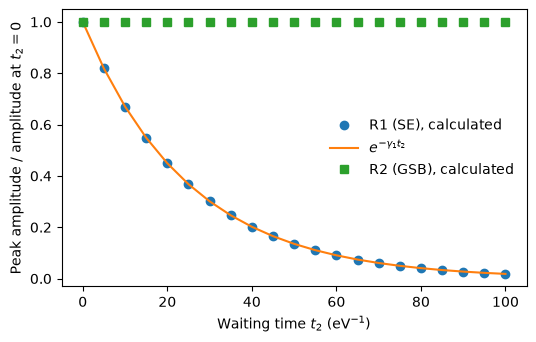

max deviation: R1 from exp(-gamma_1 t2) = 1.1e-16, R2 from 1 = 0.0e+00


In [4]:
solver = SpectroscopySolver(backend="dense", eta=eta)
solver.feed_model(example1_model())
peak_axes = {"omega_1q": np.array([-omega_eg]), "omega_emit": np.array([omega_eg])}


def at_peak(t2=EX1["t2"], observables=None):
    """Spectrum evaluated at (-omega_eg, +omega_eg) for both pathways."""
    return solver.generate_spectrum(
        EX1_PROTOCOL, peak_axes, pathways=EX1_PATHWAYS,
        fixed_coordinates={"t2": t2}, observables=observables,
    )


t2_values = np.linspace(0.0, 100.0, 21)
amplitude = {"R1": [], "R2": []}
for t2 in t2_values:
    result = at_peak(t2)
    for name in amplitude:
        amplitude[name].append(np.abs(result.pathways[name][0, 0]))
amplitude = {name: np.array(values) / values[0] for name, values in amplitude.items()}

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(t2_values, amplitude["R1"], "o", label="R1 (SE), calculated")
ax.plot(t2_values, np.exp(-gamma_1 * t2_values), "-", label=r"$e^{-\gamma_1 t_2}$")
ax.plot(t2_values, amplitude["R2"], "s", label="R2 (GSB), calculated")
ax.set_xlabel(r"Waiting time $t_2$ (eV$^{-1}$)")
ax.set_ylabel(r"Peak amplitude / amplitude at $t_2=0$")
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example1_waiting_time.pdf", bbox_inches="tight")
plt.show()

error_R1 = np.abs(amplitude["R1"] - np.exp(-gamma_1 * t2_values)).max()
error_R2 = np.abs(amplitude["R2"] - 1.0).max()
print(f"max deviation: R1 from exp(-gamma_1 t2) = {error_R1:.1e}, R2 from 1 = {error_R2:.1e}")
assert error_R1 < 1e-10 and error_R2 < 1e-10

## 3. Fluorescence window

Radiative jumps are counted at rate $\gamma_1P_e$ over a window $[0,T]$ after the projection pulse. The ratio of the integrated fluorescence to the action population is therefore $1-e^{-\gamma_1T}$, which tends to 1 once $T\gg1/\gamma_1$.

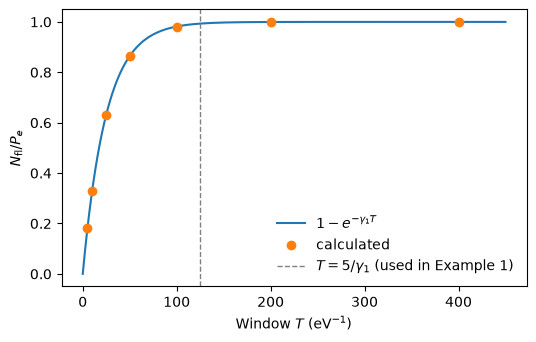

max |N_fl/P_e - (1 - exp(-gamma_1 T))| = 6.7e-16


In [5]:
channel = solver.jump_channel_names()[0]
windows = np.array([5, 10, 25, 50, 100, 200, 400])
ratio = []
for T in windows:
    observables = {
        "population": ObservableSpec.action("population", fourth_interaction="Bu", operator="excited_population"),
        "fluorescence": ObservableSpec.mean_jump("fluorescence", channel, time_window=(0.0, T), fourth_interaction="Bu"),
    }
    result = at_peak(observables=observables)
    ratio.append((result.observables["fluorescence"]["R1"][0, 0] / result.observables["population"]["R1"][0, 0]).real)
ratio = np.array(ratio)

window_axis = np.linspace(0, 450, 200)
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(window_axis, 1 - np.exp(-gamma_1 * window_axis), label=r"$1-e^{-\gamma_1T}$")
ax.plot(windows, ratio, "o", label="calculated")
ax.axvline(5 / gamma_1, color="0.5", ls="--", lw=1, label=r"$T=5/\gamma_1$ (used in Example 1)")
ax.set_xlabel(r"Window $T$ (eV$^{-1}$)")
ax.set_ylabel(r"$N_{\rm fl}/P_e$")
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example1_fluorescence_window.pdf", bbox_inches="tight")
plt.show()

window_error = np.abs(ratio - (1 - np.exp(-gamma_1 * windows))).max()
print(f"max |N_fl/P_e - (1 - exp(-gamma_1 T))| = {window_error:.1e}")
assert window_error < 1e-10

## 4. Which fourth interaction closes the response?

The third-order response ends in the optical coherence $q=+1$. A fourth interaction can bring it to a population ($q=0$) only if it carries $q=-1$: `Bu` (bra, raising) and `Kd` (ket, lowering). The two act on opposite sides of the density matrix: `Bu` writes the *excited* population, `Kd` the *ground* population. `Ku` and `Bd` push the coherence to $q=+2$, where any population observable vanishes.

We compute all 8 combinations and compare each with the polarization.

In [6]:
labels = ("Bu", "Bd", "Ku", "Kd")
operators = ("excited_population", "ground_population")
observables = {"polarization": "polarization"}
for label in labels:
    for operator in operators:
        observables[f"{label}/{operator}"] = ObservableSpec.action(
            f"{label}/{operator}", fourth_interaction=label, operator=operator
        )
result = at_peak(observables=observables)


def signal(name):
    return sum(result.observables[name][path][0, 0] for path in ("R1", "R2"))


reference = abs(signal("polarization"))
print(f"{'':>4}  {'P_e':>8}  {'P_g':>8}   (|signal| / |polarization|)")
table = np.zeros((4, 2))
for a, label in enumerate(labels):
    for b, operator in enumerate(operators):
        table[a, b] = abs(signal(f"{label}/{operator}")) / reference
    print(f"{label:>4}  {table[a, 0]:8.3f}  {table[a, 1]:8.3f}")

expected = np.array([[1, 0], [0, 0], [0, 0], [0, 1]], dtype=float)   # Bu -> P_e, Kd -> P_g
assert np.allclose(table, expected, atol=1e-10)

           P_e       P_g   (|signal| / |polarization|)
  Bu     1.000     0.000
  Bd     0.000     0.000
  Ku     0.000     0.000
  Kd     0.000     1.000


Only `(Bu, P_e)` and `(Kd, P_g)` are non-zero, and each equals the polarization in modulus ($S^{(4)}=\mp i\,S^{(3)}_{\rm pol}$): the projection is exact. `fourth_interaction` also accepts a sequence of interactions, so both branches can be summed in one observable; this becomes necessary once a doubly excited manifold contributes.

## 5. Exact versus trapezoidal jump integral

`ObservableSpec.mean_jump` integrates the jump rate over $[0,T]$ in the Heisenberg picture by default (`integration="exact"`). The legacy option `integration="trapezoid"` samples the window at `n_steps` points. At $T=5/\gamma_1$ the target is $1-e^{-5}$.

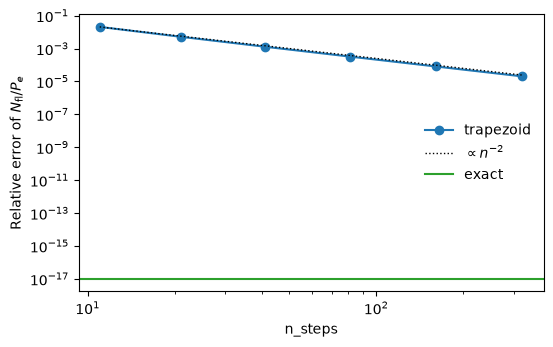

exact error: 0.0e+00; trapezoid converges as n^-2.05


In [7]:
T = 5 / gamma_1
target = 1 - np.exp(-5)


def fluorescence_ratio(**options):
    obs = {
        "population": ObservableSpec.action("population", fourth_interaction="Bu", operator="excited_population"),
        "fluorescence": ObservableSpec.mean_jump("fluorescence", channel, time_window=(0.0, T),
                                                 fourth_interaction="Bu", **options),
    }
    r = at_peak(observables=obs)
    return (r.observables["fluorescence"]["R1"][0, 0] / r.observables["population"]["R1"][0, 0]).real


n_steps = np.array([11, 21, 41, 81, 161, 321])
trapezoid_error = np.array([abs(fluorescence_ratio(integration="trapezoid", n_steps=n) - target) / target for n in n_steps])
exact_error = abs(fluorescence_ratio() - target) / target

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.loglog(n_steps, trapezoid_error, "o-", label="trapezoid")
ax.loglog(n_steps, trapezoid_error[0] * (n_steps[0] / n_steps) ** 2, "k:", lw=1, label=r"$\propto n^{-2}$")
ax.axhline(max(exact_error, 1e-17), color="C2", label="exact")
ax.set_xlabel("n_steps")
ax.set_ylabel("Relative error of $N_{\\rm fl}/P_e$")
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example1_quadrature.pdf", bbox_inches="tight")
plt.show()

order = np.polyfit(np.log(n_steps), np.log(trapezoid_error), 1)[0]
print(f"exact error: {exact_error:.1e}; trapezoid converges as n^{order:.2f}")
assert exact_error < 1e-12 and -2.3 < order < -1.7

## Summary

- The fine map of the example has the expected linewidth, $2\sqrt3(\gamma_1/2+\gamma_\phi+\eta)$.
- $R_1$ decays as $e^{-\gamma_1t_2}$ and $R_2$ stays constant, so the solver separates SE from GSB.
- The integrated fluorescence follows $1-e^{-\gamma_1T}$ at all windows.
- Only `Bu` with the excited population and `Kd` with the ground population close the response onto a population; all other combinations vanish.
- The exact jump integral is accurate to machine precision; the trapezoid rule converges as $n^{-2}$.